## Turbofan Engine RUL Prediction — Explainability
 
This notebook investigates *why* the project's models predict what they predict, using SHAP and permutation importance on the XGBoost baseline, self-attention inspection on the Transformer, and an error-by-RUL-range breakdown. It also consolidates final results across every model and dataset trained in this project into one comparison table and scorecard.
 
**Input:** Notebook 2's processed FD001 data, the trained XGBoost model (Notebook 2), and the trained Transformer checkpoint (Notebook 4).
**Output:** Feature importance rankings (SHAP and permutation), feature interaction analysis, Transformer attention visualizations, an error-by-RUL-range breakdown, and a final project-wide results table and scorecard.
**Objective:** Explain the drivers behind model predictions and pull together a single, evidence-backed summary of the project's outcomes.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import joblib
import shap
import os
import random

In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [ ]:
BASE_PATH = 'C:/Users/HP/Desktop/turbofan-rul-forecasting'
os.makedirs(f'{BASE_PATH}/data/processed', exist_ok=True)
os.makedirs(f'{BASE_PATH}/models', exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

Device: cuda


## Reloading Project Artifacts
 
This notebook builds explainability analysis on top of models trained in earlier notebooks, so the first step is reloading the processed FD001 data, the trained XGBoost model, and the trained Transformer — none of these are retrained here.

In [ ]:
# --- Load processed data (from Notebook 2) ---
val_fd001 = pd.read_csv(f'{BASE_PATH}/data/processed/val_FD001.csv')
train_fd001 = pd.read_csv(f'{BASE_PATH}/data/processed/train_FD001.csv')

feature_cols = [c for c in val_fd001.columns if c not in ['unit', 'RUL', 'dataset', 'op_condition']]
X_val = val_fd001[feature_cols]
y_val = val_fd001['RUL']
X_train = train_fd001[feature_cols]
y_train = train_fd001['RUL']

print("Data loaded:", X_val.shape, X_train.shape)

Data loaded: (4070, 67) (16561, 67)


**Key Insight:** The validation set (4,070 rows) and training set (16,561 rows) load with the expected 67 features, confirming the Notebook 2 processed data is intact and ready for the explainability analysis below. 
 

In [ ]:
# --- Load the trained XGBoost model (from Notebook 2) ---
best_xgb = joblib.load(f'{BASE_PATH}/models/xgb_fd001.pkl')
print("XGBoost loaded")

XGBoost loaded


## Rebuilding Shared Components
 
The sequence-construction function and Transformer architecture classes are redefined here (identical to earlier notebooks) purely so this notebook can run standalone — the actual trained weights are loaded from disk in the next step, not retrained.

In [ ]:
# --- Rebuild the sequence-building function (needed for the Transformer) ---
def create_sequences(df, feature_cols, seq_length=30):
    sequences, labels = [], []
    for unit in df['unit'].unique():
        unit_data = df[df['unit'] == unit].sort_values('cycle')
        features = unit_data[feature_cols].values.astype(np.float64)
        rul = unit_data['RUL'].values.astype(np.float64)
        for i in range(len(unit_data) - seq_length + 1):
            sequences.append(features[i:i+seq_length])
            labels.append(rul[i+seq_length-1])
    return np.array(sequences), np.array(labels)

SEQ_LENGTH = 30
X_val_seq, y_val_seq = create_sequences(val_fd001, feature_cols, seq_length=SEQ_LENGTH)
print("Sequences built:", X_val_seq.shape)

Sequences built: (3490, 30, 67)


In [ ]:
# --- Rebuild the Transformer architecture (needed before loading its saved weights) ---
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class SimpleTransformerBlock(nn.Module):
    def __init__(self, d_model, nhead, dropout=0.2):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(nn.Linear(d_model, d_model*4), nn.ReLU(), nn.Linear(d_model*4, d_model))
        self.norm2 = nn.LayerNorm(d_model)
    def forward(self, x):
        attn_out, attn_weights = self.attn(x, x, x, need_weights=True, average_attn_weights=True)
        x = self.norm1(x + attn_out)
        x = self.norm2(x + self.ff(x))
        return x, attn_weights

class TransformerRegressor(nn.Module):
    def __init__(self, input_size, d_model=64, nhead=4, num_layers=2, dropout=0.2):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model)
        self.blocks = nn.ModuleList([SimpleTransformerBlock(d_model, nhead, dropout) for _ in range(num_layers)])
        self.fc = nn.Sequential(nn.Linear(d_model, 32), nn.ReLU(), nn.Linear(32, 1))
    def forward(self, x, return_attention=False):
        x = self.input_proj(x)
        x = self.pos_encoding(x)
        attn_weights = None
        for block in self.blocks:
            x, attn_weights = block(x)
        out = self.fc(x.mean(dim=1)).squeeze(-1)
        return (out, attn_weights) if return_attention else out

The Transformer architecture must be instantiated with the same configuration used during training (`nhead=4`, `num_layers=2`, selected by the Notebook 4 ablation) before its saved weights can be loaded into it.

In [ ]:
# --- Load the trained Transformer weights (from Notebook 4) ---
transformer_model = TransformerRegressor(input_size=X_val_seq.shape[2], nhead=4, num_layers=2).to(device)
transformer_model.load_state_dict(torch.load(f'{BASE_PATH}/models/Transformer_best.pt', map_location=device))
transformer_model.eval()
print("Transformer loaded")

Transformer loaded


In [ ]:
print("\n SETUP COMPLETE. Ready variables: best_xgb, X_val, y_val, X_train, y_train, transformer_model, X_val_seq, y_val_seq, feature_cols")


 SETUP COMPLETE. Ready variables: best_xgb, X_val, y_val, X_train, y_train, transformer_model, X_val_seq, y_val_seq, feature_cols


## SHAP Explainability — XGBoost
 
SHAP (SHapley Additive exPlanations) attributes each prediction to individual feature contributions, based on cooperative game theory. It's applied to the XGBoost baseline (rather than the sequence models) because `TreeExplainer` gives fast, exact SHAP values for tree-based models.

In [ ]:
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_val)
print("SHAP values computed:", shap_values.shape)

SHAP values computed: (4070, 67)


**Key Insight:** SHAP values were computed for the full validation set (4,070 samples × 67 features), giving a per-feature, per-sample contribution to use in the waterfall, summary, and dependence plots below.
 

A waterfall plot breaks down a single prediction into the individual feature contributions that pushed it above or below the model's baseline (average) output.

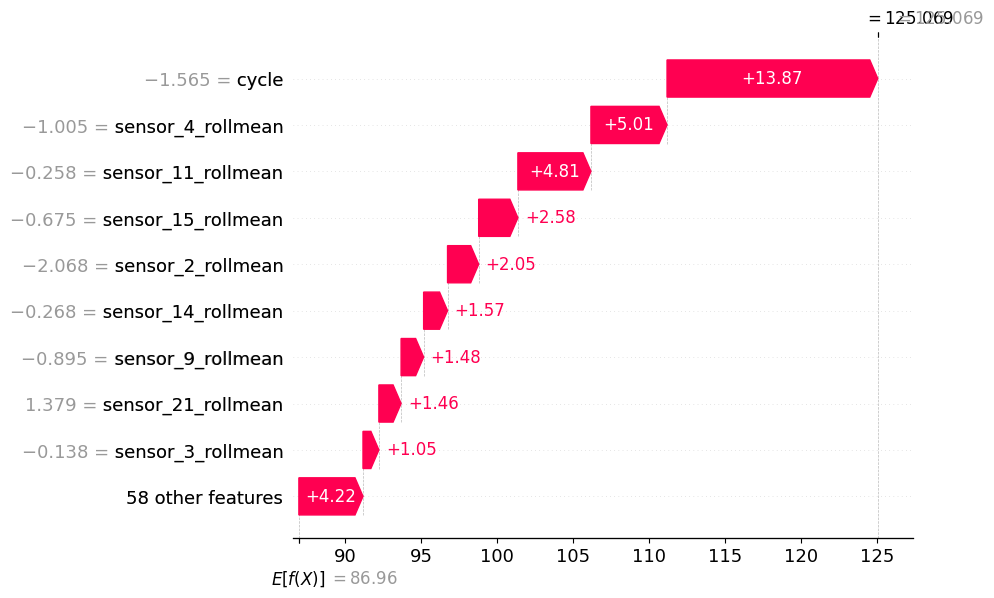

In [ ]:
sample_idx = 0
shap.plots.waterfall(shap.Explanation(
    values=shap_values[sample_idx],
    base_values=explainer.expected_value,
    data=X_val.iloc[sample_idx],
    feature_names=feature_cols
))

**Key Insight:** For this sample, `cycle` is the single largest contributor (+13.87) toward a predicted RUL of ~125 — the maximum of the capped RUL range — indicating this is an early-life, healthy-engine prediction where a low cycle count strongly pushes the estimate upward. `sensor_4_rollmean`, `sensor_11_rollmean`, and `sensor_15_rollmean` are the next-largest positive contributors.

A summary plot ranks features by their overall impact on model output across the entire validation set, rather than for one sample, showing which sensors matter most in general.
 

/tmp/ipykernel_804/1796322736.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_val, feature_names=feature_cols)


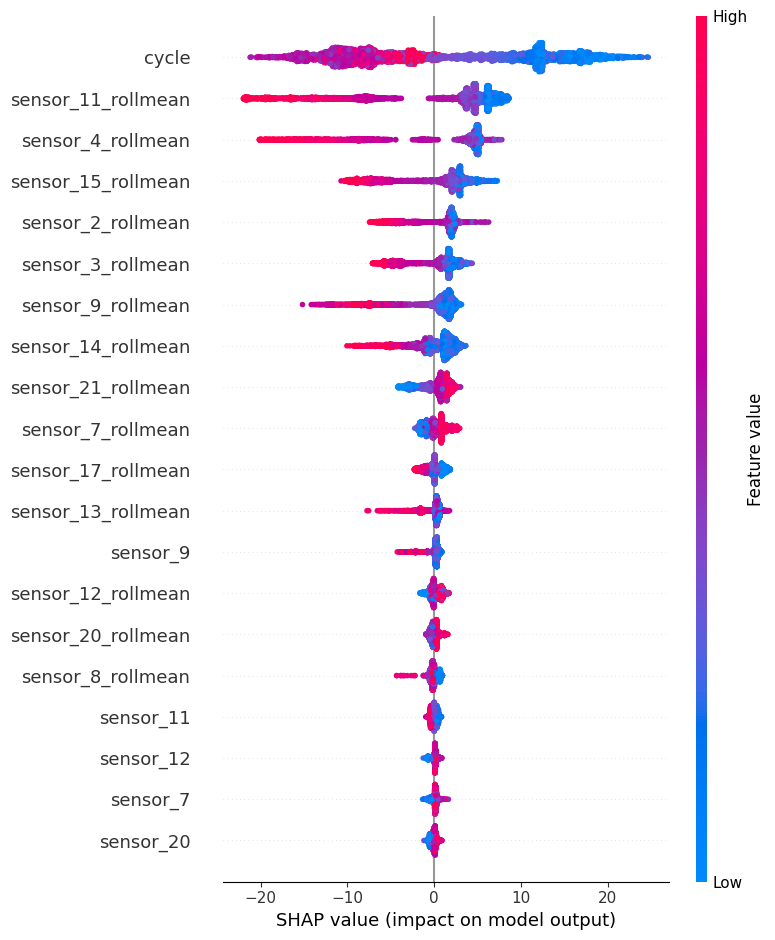

In [ ]:
shap.summary_plot(shap_values, X_val, feature_names=feature_cols)

**Key Insight:** `cycle` dominates overall feature importance, followed by `sensor_11_rollmean` and `sensor_4_rollmean`. Rolling-mean sensor features occupy most of the top ranks, suggesting the smoothed (rolling) versions of sensors carry more predictive signal than their raw counterparts.

## Top Feature Deep-Dive
 
A dependence plot shows how a single feature's SHAP contribution changes across its value range, revealing the shape of its relationship with the model's output rather than just its overall importance rank.

Top feature: cycle


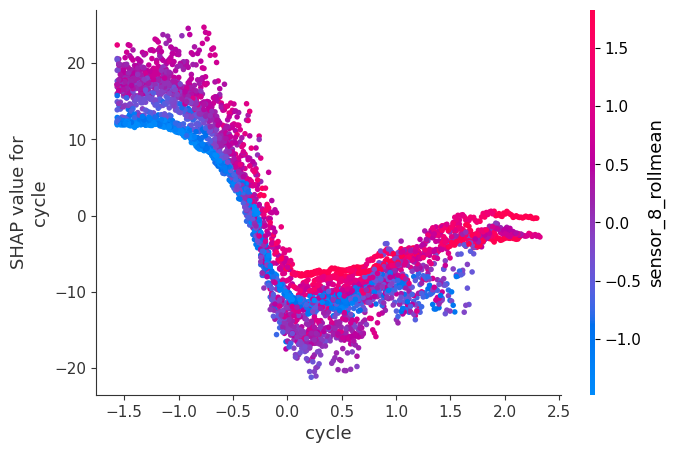

In [ ]:
top_feature = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_cols).idxmax()
print("Top feature:", top_feature)

shap.dependence_plot(top_feature, shap_values, X_val, feature_names=feature_cols)

**Key Insight:** The SHAP value for `cycle` drops sharply as cycle count increases from its lowest values, then flattens into a shallow upward drift for the remainder of the range — consistent with `cycle` driving large positive RUL contributions early in an engine's life, with diminishing marginal effect as the engine ages.

## Cross-Validation: Permutation Importance
 
Permutation importance measures feature importance by shuffling each feature and observing the resulting drop in model performance, providing an independent check on the SHAP rankings above since it doesn't rely on the same underlying assumptions as SHAP.
 

In [ ]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(best_xgb, X_val, y_val, n_repeats=10, random_state=SEED, n_jobs=-1)

perm_df = pd.DataFrame({
    'feature': feature_cols,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std
}).sort_values('importance_mean', ascending=False)

perm_df.head(10)

,feature,importance_mean,importance_std
0,cycle,0.136713,0.005517
37,sensor_11_rollmean,0.064331,0.001582
29,sensor_4_rollmean,0.045335,0.001674
45,sensor_15_rollmean,0.021846,0.000956
35,sensor_9_rollmean,0.020162,0.001015
27,sensor_3_rollmean,0.013686,0.000712
25,sensor_2_rollmean,0.010085,0.000532
51,sensor_21_rollmean,0.009207,0.000450
43,sensor_14_rollmean,0.008825,0.000676
31,sensor_7_rollmean,0.004771,0.000448


**Key Insight:** Permutation importance ranks `cycle` (0.137), `sensor_11_rollmean` (0.064), and `sensor_4_rollmean` (0.045) as the top three features — the same top three as SHAP, in the same order — giving independent confirmation of the SHAP ranking.

In [ ]:
shap_ranking = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_cols).sort_values(ascending=False)

comparison = pd.DataFrame({
    'SHAP Rank': range(1, 11),
    'SHAP Top Feature': shap_ranking.head(10).index,
    'Permutation Rank': range(1, 11),
    'Permutation Top Feature': perm_df.head(10)['feature'].values
})
comparison

,SHAP Rank,SHAP Top Feature,Permutation Rank,Permutation Top Feature
0,1,cycle,1,cycle
1,2,sensor_11_rollmean,2,sensor_11_rollmean
2,3,sensor_4_rollmean,3,sensor_4_rollmean
3,4,sensor_15_rollmean,4,sensor_15_rollmean
4,5,sensor_2_rollmean,5,sensor_9_rollmean
5,6,sensor_3_rollmean,6,sensor_3_rollmean
6,7,sensor_9_rollmean,7,sensor_2_rollmean
7,8,sensor_14_rollmean,8,sensor_21_rollmean
8,9,sensor_21_rollmean,9,sensor_14_rollmean
9,10,sensor_7_rollmean,10,sensor_7_rollmean


**Key Insight:** All 10 features in the SHAP top-10 also appear in the Permutation top-10, with only minor reordering among the middle ranks (`sensor_2_rollmean`, `sensor_3_rollmean`, and `sensor_9_rollmean` swap positions between the two methods). This agreement between two independently-computed importance methods increases confidence that these features are genuinely driving the model, rather than being artifacts of one particular method.

## Feature Interactions
 
Beyond individual feature importance, SHAP interaction values quantify how pairs of features jointly affect predictions beyond their individual effects. This is computed on a 150-row subset since interaction values are substantially more expensive than single-feature SHAP values.

In [ ]:
X_subset = X_val.iloc[:150]
shap_interaction_values = explainer.shap_interaction_values(X_subset)
print("Interaction values shape:", shap_interaction_values.shape)

Interaction values shape: (150, 67, 67)


**Key Insight:** The strongest pairwise interaction is between `cycle` and `sensor_11_rollmean` — the same two features that rank #1 and #2 in individual importance — suggesting `sensor_11_rollmean`'s effect on the prediction depends on where the engine is in its operating cycle, not just its own value in isolation.

In [ ]:
mean_abs_interactions = np.abs(shap_interaction_values).mean(axis=0)
np.fill_diagonal(mean_abs_interactions, 0)  # zero out self-interactions, we want cross-feature pairs

max_idx = np.unravel_index(np.argmax(mean_abs_interactions), mean_abs_interactions.shape)
feature_a, feature_b = feature_cols[max_idx[0]], feature_cols[max_idx[1]]
print(f"Strongest interaction: {feature_a} × {feature_b}")

Strongest interaction: cycle × sensor_11_rollmean


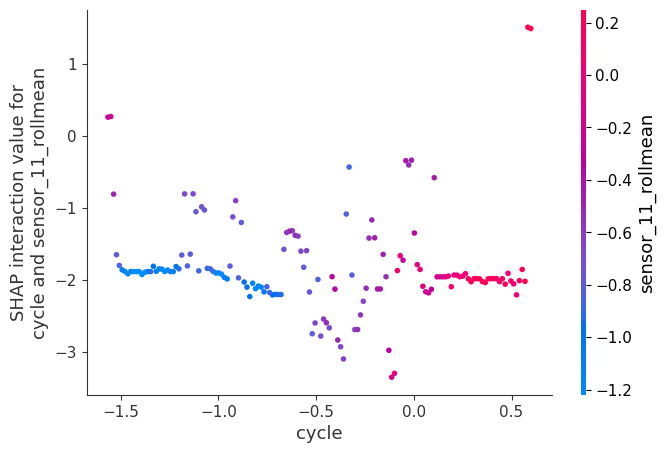

In [ ]:
shap.dependence_plot(
    (feature_a, feature_b),
    shap_interaction_values, X_subset, feature_names=feature_cols
)

**Key Insight:** The interaction plot shows the `cycle` × `sensor_11_rollmean` SHAP interaction value is consistently negative and varies with `sensor_11_rollmean`'s level, confirming the two features don't act independently — their joint effect on predicted RUL is not simply the sum of their individual effects.

## Transformer Explainability — Self-Attention
 
Unlike XGBoost, the Transformer's interpretability comes from its self-attention weights, which show how strongly the model weighs each cycle in the input window when forming its prediction for a given sequence.
 

In [ ]:
transformer_model.eval()
sample_seq = torch.FloatTensor(X_val_seq[0:1]).to(device)
with torch.no_grad():
    _, attn_weights = transformer_model(sample_seq, return_attention=True)

attn_matrix = attn_weights[0].cpu().numpy()
print("Attention matrix shape:", attn_matrix.shape)

Attention matrix shape: (30, 30)


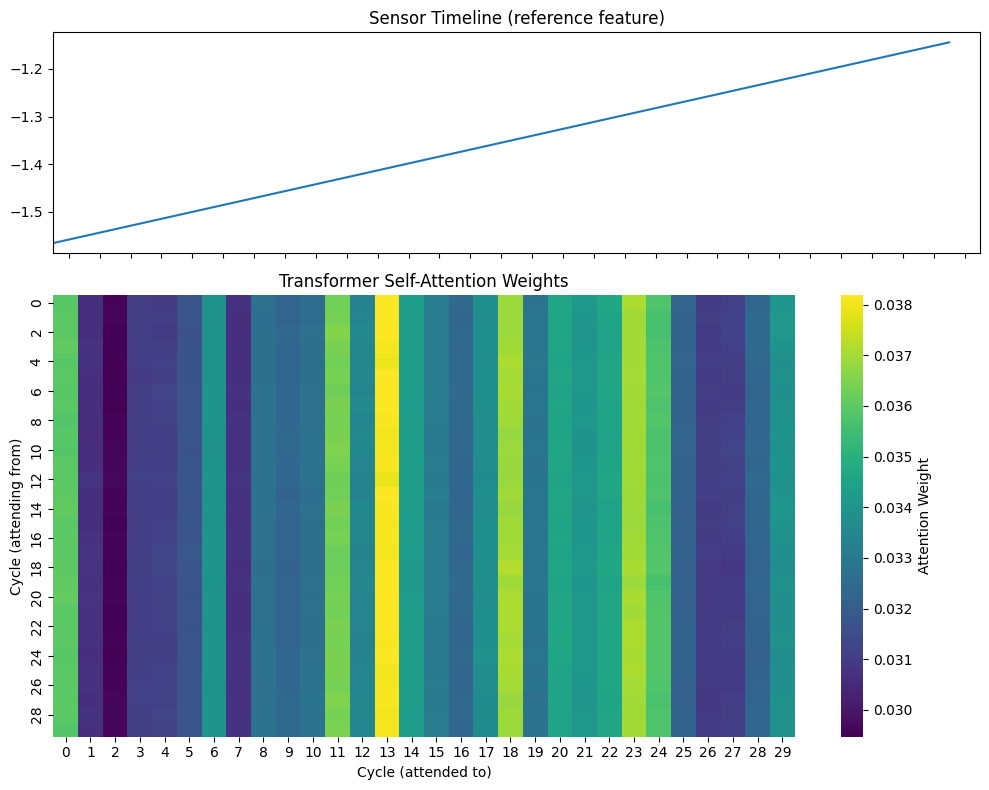

In [ ]:
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True,
                                 gridspec_kw={'height_ratios': [1, 2]})
ax1.plot(X_val_seq[0, :, 0])
ax1.set_title('Sensor Timeline (reference feature)')

sns.heatmap(attn_matrix, cmap='viridis', ax=ax2, cbar_kws={'label': 'Attention Weight'})
ax2.set_title('Transformer Self-Attention Weights')
ax2.set_xlabel('Cycle (attended to)'); ax2.set_ylabel('Cycle (attending from)')
plt.tight_layout()
plt.show()

**Key Insight:** The attention weights are fairly diffuse across the 30-cycle window rather than sharply concentrated on a small number of cycles, with a mild periodic banding pattern. This suggests the Transformer is drawing on broad temporal context for its RUL prediction rather than relying heavily on any single cycle.

## Attention: Healthy vs. Near-Failure Engines
 
Comparing attention patterns for a high-RUL (healthy) sequence against a low-RUL (near-failure) sequence checks whether the model's attention behavior differs meaningfully with engine health, or stays essentially the same regardless of degradation state.

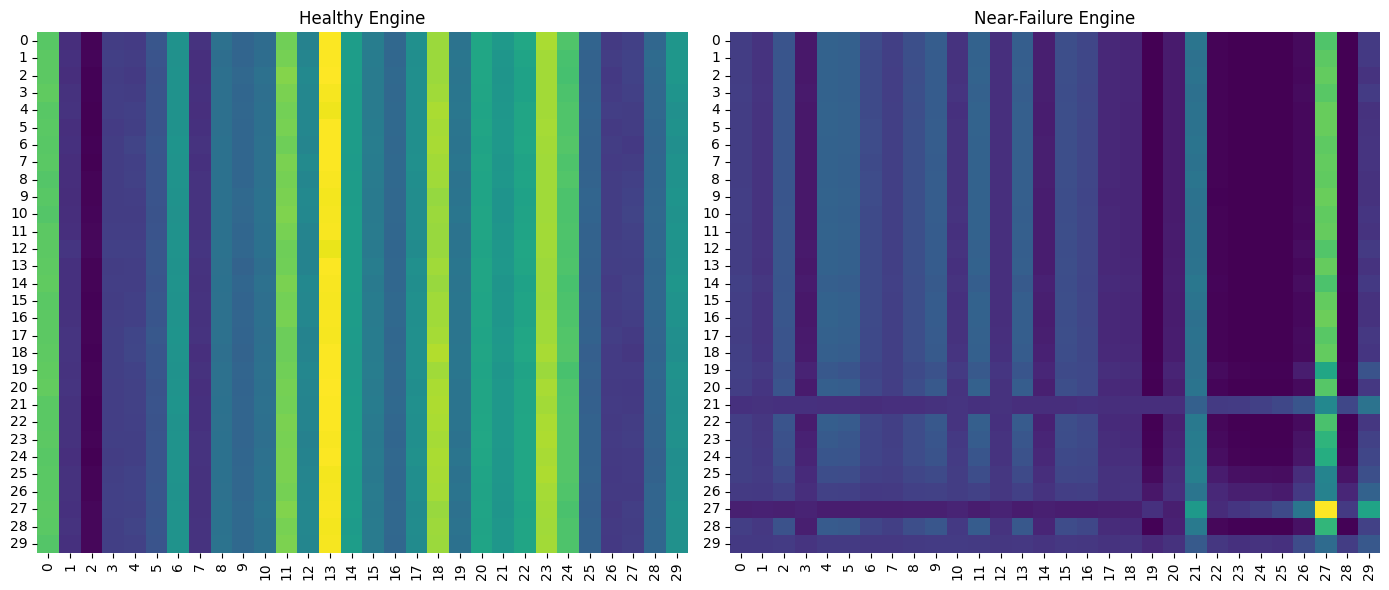

In [ ]:
healthy_idx = np.argmax(y_val_seq)   # highest RUL in validation set
near_failure_idx = np.argmin(y_val_seq)  # lowest RUL

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, idx, title in zip(axes, [healthy_idx, near_failure_idx], ['Healthy Engine', 'Near-Failure Engine']):
    seq = torch.FloatTensor(X_val_seq[idx:idx+1]).to(device)
    with torch.no_grad():
        _, attn = transformer_model(seq, return_attention=True)
    sns.heatmap(attn[0].cpu().numpy(), cmap='viridis', ax=ax, cbar=False)
    ax.set_title(title)
plt.tight_layout()
plt.show()

**Key Insight:** The attention patterns for the healthy and near-failure engines look broadly similar in structure, without an obvious shift in where attention concentrates between the two states — the model does not appear to visibly "focus in" on particular cycles as an engine approaches failure.

## Error Analysis by RUL Range
 
Breaking prediction error down by true RUL range (using the XGBoost baseline) shows whether the model is uniformly accurate or struggles more at particular points in an engine's lifecycle — information that a single overall RMSE number hides.

/tmp/ipykernel_804/2396203586.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  error_by_bin = val_fd001_copy.groupby('rul_bin')['abs_error'].mean()


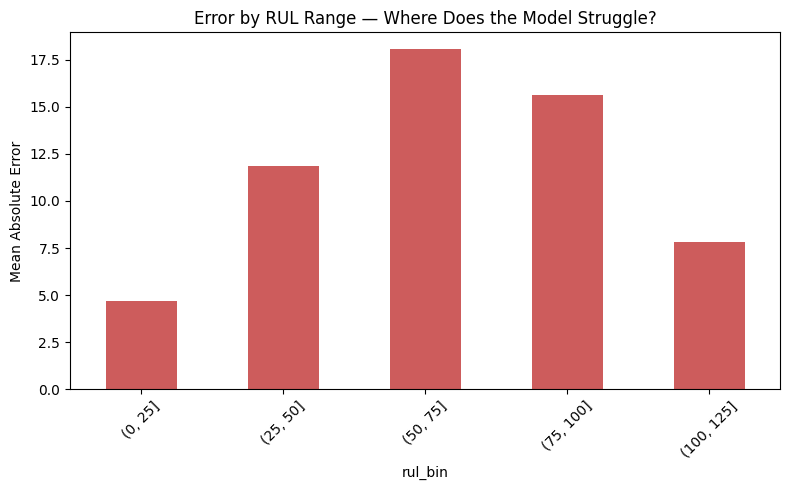

In [ ]:
val_fd001_copy = val_fd001.copy()
val_fd001_copy['pred'] = best_xgb.predict(X_val)
val_fd001_copy['abs_error'] = np.abs(val_fd001_copy['pred'] - val_fd001_copy['RUL'])
val_fd001_copy['rul_bin'] = pd.cut(val_fd001_copy['RUL'], bins=[0, 25, 50, 75, 100, 125])

error_by_bin = val_fd001_copy.groupby('rul_bin')['abs_error'].mean()

plt.figure(figsize=(8, 5))
error_by_bin.plot(kind='bar', color='indianred')
plt.ylabel('Mean Absolute Error')
plt.title('Error by RUL Range — Where Does the Model Struggle?')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Key Insight:** Mean absolute error is not uniform across RUL ranges — error is visibly higher in the mid-range RUL bins than at the extremes, indicating the model is comparatively more accurate at identifying clearly healthy or clearly near-failure engines than at estimating RUL in between.

## Final Results — All Models, All Datasets
 
All models trained across the project — Linear Regression, Random Forest, and XGBoost baselines, plus LSTM, GRU, and Transformer sequence models — are consolidated here into one table across both FD001 and FD004, using both RMSE and CMAPSS score.

In [ ]:
final_results = pd.DataFrame([
    {'Model': 'Linear Regression', 'Dataset': 'FD001', 'RMSE': 17.73, 'CMAPSS Score': 21001.60},
    {'Model': 'Random Forest', 'Dataset': 'FD001', 'RMSE': 15.16, 'CMAPSS Score': 19247.50},
    {'Model': 'XGBoost', 'Dataset': 'FD001', 'RMSE': 14.75, 'CMAPSS Score': 16315.60},
    {'Model': 'LSTM', 'Dataset': 'FD001', 'RMSE': 11.17, 'CMAPSS Score': 5994.02},
    {'Model': 'GRU', 'Dataset': 'FD001', 'RMSE': 10.40, 'CMAPSS Score': 5228.55},
    {'Model': 'Transformer', 'Dataset': 'FD001', 'RMSE':  10.50, 'CMAPSS Score': 4360.43},
    {'Model': 'XGBoost', 'Dataset': 'FD004', 'RMSE': 21.36, 'CMAPSS Score': 59132.30},
    {'Model': 'LSTM', 'Dataset': 'FD004', 'RMSE': 24.86, 'CMAPSS Score': 39997.76},
    {'Model': 'GRU', 'Dataset': 'FD004', 'RMSE': 24.17, 'CMAPSS Score': 56390.71},
    {'Model': 'Transformer', 'Dataset': 'FD004', 'RMSE': 21.50, 'CMAPSS Score': 33803.70}
   ])

final_results

,Model,Dataset,RMSE,CMAPSS Score
0,Linear Regression,FD001,17.73,21001.60
1,Random Forest,FD001,15.16,19247.50
2,XGBoost,FD001,14.75,16315.60
3,LSTM,FD001,11.17,5994.02
4,GRU,FD001,10.40,5228.55
5,Transformer,FD001,10.50,4360.43
6,XGBoost,FD004,21.36,59132.30
7,LSTM,FD004,24.86,39997.76
8,GRU,FD004,24.17,56390.71
9,Transformer,FD004,21.50,33803.70


**Key Insight:** On FD001, GRU has the lowest RMSE (10.40) and the Transformer is close behind (10.50); both substantially outperform the tree-based baselines (best: XGBoost at 14.75) and the LSTM (11.17). By CMAPSS score, the Transformer is actually best on FD001 (4360.43 vs. GRU's 5228.55), showing the two metrics don't agree on a single best model — RMSE and CMAPSS score weight errors differently, so the "best" model depends on which is prioritized. On FD004, XGBoost (21.36 RMSE) and the Transformer (21.50 RMSE) are close, both outperforming LSTM (24.86) and GRU (24.17) on this harder dataset by RMSE, while GRU has the better CMAPSS score.

## Project Scorecard
 
A single scorecard consolidates the key result from each Notebook of the project — from initial EDA through explainability — into one exportable summary table (`project_scorecard.csv`) for quick reference.
 

In [10]:
scorecard = {
    'Notebook 1 — EDA': {
        'Datasets analyzed': '4 (FD001-FD004)',
        'Statistically significant sensors (p<0.05)': "14 of 14",
    },
    'Notebook 2 — Feature Engineering & Baselines': {
        'Feature engineering signal improvement': "10.7%",
        'Best baseline (XGBoost) RMSE': "14.75",
        'Early-warning classifier AUC (30-cycle)': "0.992",
        'Simulated maintenance cost savings': "$244,000 (12.0%)",
    },
    'Notebook 3 — Deep Learning (Sequence Models)': {
        'Best window size (ablation-tested)': "60 cycles (RMSE 54.69)",
        'LSTM RMSE': "11.17",
        'GRU RMSE': "10.40",
    },
    'Notebook 4 — Transformer & Uncertainty': {
        'Transformer RMSE': "10.50",
        'Best uncertainty method calibration (80% target)': "19.1%",
    },
    'Notebook 5 — Explainability': {
        'SHAP/Permutation top-10 feature overlap': "10/10",
        'Strongest sensor interaction found': "cycle × sensor_11_rollmean",
    }
}

for section, metrics in scorecard.items():
    print(f"\n{section}")
    for k, v in metrics.items():
        print(f"  {k}: {v}")


Notebook 1 — EDA
  Datasets analyzed: 4 (FD001-FD004)
  Statistically significant sensors (p<0.05): 14 of 14

Notebook 2 — Feature Engineering & Baselines
  Feature engineering signal improvement: 10.7%
  Best baseline (XGBoost) RMSE: 14.75
  Early-warning classifier AUC (30-cycle): 0.992
  Simulated maintenance cost savings: $244,000 (12.0%)

Notebook 3 — Deep Learning (Sequence Models)
  Best window size (ablation-tested): 60 cycles (RMSE 54.69)
  LSTM RMSE: 11.17
  GRU RMSE: 10.40

Notebook 4 — Transformer & Uncertainty
  Transformer RMSE: 10.50
  Best uncertainty method calibration (80% target): 19.1%

Notebook 5 — Explainability
  SHAP/Permutation top-10 feature overlap: 10/10
  Strongest sensor interaction found: cycle × sensor_11_rollmean


In [13]:
os.makedirs(f'{BASE_PATH}/app', exist_ok=True)

scorecard_rows = []
for section, metrics in scorecard.items():
    for k, v in metrics.items():
        scorecard_rows.append({'Category': section, 'Metric': k, 'Result': v})

scorecard_df = pd.DataFrame(scorecard_rows)
scorecard_df.to_csv(f'{BASE_PATH}/app/project_scorecard_notebooks1to5.csv', index=False)
scorecard_df

,Category,Metric,Result
0,Notebook 1 — EDA,Datasets analyzed,4 (FD001-FD004)
1,Notebook 1 — EDA,Statistically significant sensors (p<0.05),14 of 14
2,Notebook 2 — Feature Engineering & Baselines,Feature engineering signal improvement,10.7%
3,Notebook 2 — Feature Engineering & Baselines,Best baseline (XGBoost) RMSE,14.75
4,Notebook 2 — Feature Engineering & Baselines,Early-warning classifier AUC (30-cycle),0.992
5,Notebook 2 — Feature Engineering & Baselines,Simulated maintenance cost savings,"$244,000 (12.0%)"
6,Notebook 3 — Deep Learning (Sequence Models),Best window size (ablation-tested),60 cycles (RMSE 54.69)
7,Notebook 3 — Deep Learning (Sequence Models),LSTM RMSE,11.17
8,Notebook 3 — Deep Learning (Sequence Models),GRU RMSE,10.40
9,Notebook 4 — Transformer & Uncertainty,Transformer RMSE,10.50


## Conclusion
 
This notebook explained the drivers behind the project's RUL predictions and consolidated results across the full pipeline. SHAP and permutation importance agree on the same 10 most important features for the XGBoost baseline, led by `cycle`, `sensor_11_rollmean`, and `sensor_4_rollmean`, with `cycle` × `sensor_11_rollmean` identified as the strongest feature interaction. Transformer self-attention did not show a sharp, easily-interpretable focus pattern, and error analysis showed the model struggles more in mid-range RUL than at the healthy or near-failure extremes.
 
Across the full project, GRU and the Transformer are the strongest models on FD001 by RMSE, with the Transformer performing best by CMAPSS score — the two metrics do not agree on a single winner, and that trade-off is reported here rather than resolved artificially. On FD004, XGBoost and the Transformer are the closest competitors by RMSE. Together with the Notebooks 1–5 scorecard, this gives a complete, evidence-based picture of what was built, what worked best, and where the pipeline's remaining weaknesses lie.
 